In [8]:
import matplotlib.pyplot as plt
import numpy as np

# ChRmine
irr_1p = np.array([0.01, 0.05, 0.22, 0.64, 1.42])  # mW/mm2
I_1p = np.array(
    [  # nA
        0.2886803623803128,
        2.4244584619798237,
        4.114091789682305,
        4.637010169751716,
        4.663515508375585,
    ]
)
power_2p = np.array(
    [
        1.758409161619387,
        7.759939823443684,
        18.27217199407987,
        32.8363883380391,
        50.840977407076835,
    ]
)
I_2p = np.array(
    [
        0.0677292632963725,
        0.43824699419092045,
        1.1215139595623866,
        1.8266932442474064,
        2.3784859137876424,
    ]
)
# divide by area of spot with 10 μm radius:
irr_2p = np.array(power_2p) / (np.pi * 0.01**2)

ChroME2s 342367.84086207947


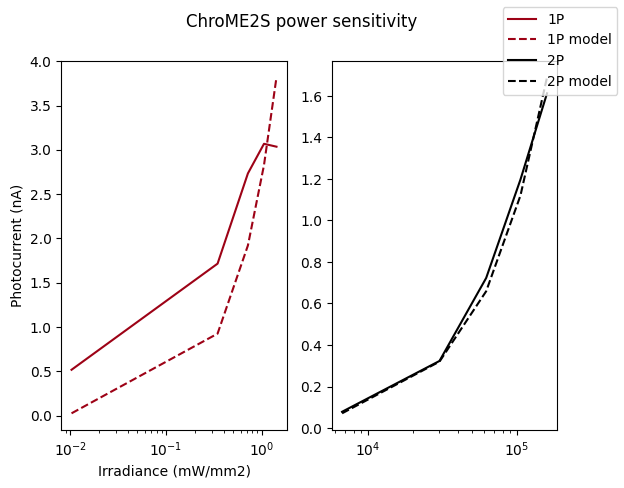

In [ ]:
fig, axs = plt.subplots(1, 2)
axs[0].semilogx(chrome2s_irr_1p, chrome2s_I_1p, c="xkcd:carmine", label="1P")
axs[0].semilogx(chrome2s_irr_1p, m1p_chrome2s * chrome2s_irr_1p, c="xkcd:carmine", linestyle="--", label="1P model")
axs[1].semilogx(chrome2s_irr_2p, chrome2s_I_2p, c="k", label="2P")
axs[1].semilogx(chrome2s_irr_2p, m2p_chrome2s * chrome2s_irr_2p, c="k", linestyle="--", label="2P model") 
axs[0].set(
    xlabel="Irradiance (mW/mm2)",
    ylabel="Photocurrent (nA)",
)
fig.suptitle("ChroME2S power sensitivity")
fig.legend()

# 1p2p just first 2 points
delta_I_1p = chrome2s_I_1p[1] - chrome2s_I_1p[0]
delta_irr_1p = chrome2s_irr_1p[1] - chrome2s_irr_1p[0]
m1p_first2 = delta_I_1p / delta_irr_1p

delta_I_2p = chrome2s_I_2p[1] - chrome2s_I_2p[0]
delta_irr_2p = chrome2s_irr_2p[1] - chrome2s_irr_2p[0]
m2p_first2 = delta_I_2p / delta_irr_2p

ratio_first2 = m1p_first2 / m2p_first2
print(f"ChroME2s {ratio_first2}")

ChroME2s 342367.84086207947


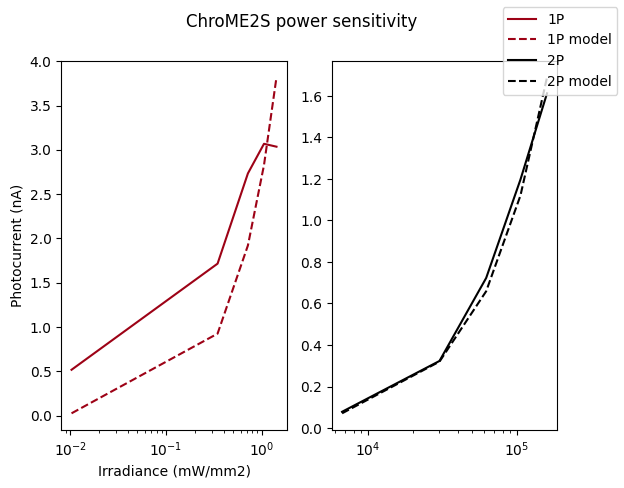

In [ ]:
fig, axs = plt.subplots(1, 2)
axs[0].semilogx(chrome2s_irr_1p, chrome2s_I_1p, c="xkcd:carmine", label="1P")
axs[0].semilogx(chrome2s_irr_1p, m1p_chrome2s * chrome2s_irr_1p, c="xkcd:carmine", linestyle="--", label="1P model")
axs[1].semilogx(chrome2s_irr_2p, chrome2s_I_2p, c="k", label="2P")
axs[1].semilogx(chrome2s_irr_2p, m2p_chrome2s * chrome2s_irr_2p, c="k", linestyle="--", label="2P model") 
axs[0].set(
    xlabel="Irradiance (mW/mm2)",
    ylabel="Photocurrent (nA)",
)
fig.suptitle("ChroME2S power sensitivity")
fig.legend()

# 1p2p just first 2 points
delta_I_1p = chrome2s_I_1p[1] - chrome2s_I_1p[0]
delta_irr_1p = chrome2s_irr_1p[1] - chrome2s_irr_1p[0]
m1p_first2 = delta_I_1p / delta_irr_1p

delta_I_2p = chrome2s_I_2p[1] - chrome2s_I_2p[0]
delta_irr_2p = chrome2s_irr_2p[1] - chrome2s_irr_2p[0]
m2p_first2 = delta_I_2p / delta_irr_2p

ratio_first2 = m1p_first2 / m2p_first2
print(f"ChroME2s {ratio_first2}")

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# ChRmine https://www.cell.com/neuron/fulltext/S0896-6273(22)00008-3 
irr_1p = np.array([0.01, 0.05, 0.22, 0.64, 1.42])  # mW/mm2
I_1p = np.array(
    [  # nA
        0.2886803623803128,
        2.4244584619798237,
        4.114091789682305,
        4.637010169751716,
        4.663515508375585,
    ]
)
power_2p = np.array(
    [
        1.758409161619387,
        7.759939823443684,
        18.27217199407987,
        32.8363883380391,
        50.840977407076835,
    ]
)
I_2p = np.array(
    [
        0.0677292632963725,
        0.43824699419092045,
        1.1215139595623866,
        1.8266932442474064,
        2.3784859137876424,
    ]
)
# divide by area of spot with 10 μm radius:
irr_2p = np.array(power_2p) / (np.pi * 0.01**2)

#reachr


In [10]:
from brian2 import pA, nA, cm, watt, second, metre, joule
nm = metre / 1e9
mW = watt / 1e3
mm = metre / 1e3

h = 6.62607015e-34 * joule * second
c = 2.99792458e8 * metre / second

    
def flux_to_irradiance(x_flux, wavelength_nm):
    I = np.asarray(x_flux, float) / (cm**2 * second) # photons / (cm^2 s)
    lam = wavelength_nm * nm
    E = I * ((h * c) / lam) # W/cm^2
    E_W_cm2 = (E / (watt / (cm**2))).astype(float)
    E_mWmm2 =  E_W_cm2 * 10.0 # mW/mm^2 
    return  E_mWmm2

def get_chr2_irradiance_data():

    #https://www.pnas.org/doi/10.1073/pnas.0907084106

    irr_1p_flux = np.array([0.33, 0.77, 1.26, 1.72]) *1e19  # flux, need mW/mm2
    irr_1p = flux_to_irradiance(irr_1p_flux, 470)
    I_1p_og = np.array([
        606.9894921, 
        705.1046238, 
        748.4110652, 
        771.2480195
    ]) * pA # pA
    I_1p = (I_1p_og / nA).astype(float)   # nA

    irr_2p_og = np.array([0.37, 0.54, 1.00, 1.53]) *1e49  # flux, need mW/mm2
    irr_2p_flux = np.sqrt(irr_2p_og) #since its i^2
    irr_2p = flux_to_irradiance(irr_2p_flux, 920)
    I_2p_og = np.array([
        0.01438881888,
        0.04539752549,
        0.08182781533,
        0.1117224195,
    ])  * pA # pA

    I_2p = (I_2p_og / nA).astype(float)  # nA


    return {
        "irr_1p": irr_1p,
        "I_1p": I_1p,
        "irr_2p": irr_2p,
        "I_2p": I_2p,
    }




In [11]:
def get_chrome():
    #https://www.cell.com/neuron/fulltext/S0896-6273(22)00008-3
    irr_1p = np.array([
        0.009524139115,
        0.3450867178,
        0.7179277543,
        1.055845441,
        1.424556973
    ])  # mW/mm²

    I_1p = np.array([
        0.1682428241,
        0.6738337696,
        1.233987502,
        1.610873216,
        1.771141945
    ])  # nA

    power_2p = np.array([
        1.881570223,
        7.899540317,
        17.85275251,
        31.84104066,
        49.06685143
    ])  # mW

    I_2p = np.array([
        0.06614448185,
        0.1085880753,
        0.3343108222,
        0.6277696856,
        0.9260323922
    ])  # nA

    irr_2p = power_2p / (np.pi * (0.01 ** 2))  # mW/mm2, assuming 10 µm r 

    return {
        "irr_1p": irr_1p,
        "I_1p": I_1p,
        "irr_2p": irr_2p,
        "I_2p": I_2p
    }
      

In [12]:
def get_chrome2f():
    #https://www.cell.com/neuron/fulltext/S0896-6273(22)00008-3
    irr_1p = np.array([
        0.007604564695,
        0.3442317813,
        0.7163953209,
        1.053683903,
        1.425710331
    ])  # mW/mm²

    I_1p = np.array([
        0.2990966727,
        1.139206222,
        2.083417815,
        2.625293165,
        2.730696485
    ])  # nA

    power_2p = np.array([
        2.132272412,
        7.947967189,
        17.89223904,
        31.72742376,
        49.03965788
    ])  # mW

    I_2p = np.array([
        0.06874897508,
        0.2226648789,
        0.6037697628,
        0.9830032701,
        1.413053334
    ])  # nA

    irr_2p = power_2p / (np.pi * (0.01 ** 2))  # mW/mm2, assuming 10 µm radius spot

    return {
        "irr_1p": irr_1p,
        "I_1p": I_1p,
        "irr_2p": irr_2p,
        "I_2p": I_2p
    }

In [13]:
def get_chrome2s():
    #https://www.cell.com/neuron/fulltext/S0896-6273(22)00008-3
    irr_1p = np.array([
        0.01033068299,
        0.345586775,
        0.7163469283,
        1.054329139,
        1.423782691
    ])  # mW/mm²

    I_1p = np.array([
        0.5189214544,
        1.716216012,
        2.733843756,
        3.06809,
        3.035437062
    ])  # nA

    power_2p = np.array([
        2.098001088,
        9.469688503,
        19.49889363,
        33.14558608,
        49.99403977
    ])  # mW

    I_2p = np.array([
        0.07833736869,
        0.323101855,
        0.7228433349,
        1.197034736,
        1.612615394
    ])  # nA

    irr_2p = power_2p / (np.pi * (0.01 ** 2))  # mW/mm2, assuming 10 µm r

    return {
        "irr_1p": irr_1p,
        "I_1p": I_1p,
        "irr_2p": irr_2p,
        "I_2p": I_2p
    }

WARNING    /var/folders/k8/vkc87z_97_9d7gp2l0pm5khr0000gn/T/ipykernel_12271/3249297530.py:57: RuntimeWarning: invalid value encountered in sqrt
  I_hat_1p = f_I_inv(m1p * irr_1p_trans)
 [py.warnings]
WARNING    /var/folders/k8/vkc87z_97_9d7gp2l0pm5khr0000gn/T/ipykernel_12271/3249297530.py:57: RuntimeWarning: invalid value encountered in sqrt
  I_hat_1p = f_I_inv(m1p * irr_1p_trans)
 [py.warnings]
WARNING    /var/folders/k8/vkc87z_97_9d7gp2l0pm5khr0000gn/T/ipykernel_12271/3249297530.py:57: RuntimeWarning: invalid value encountered in sqrt
  I_hat_1p = f_I_inv(m1p * irr_1p_trans)
 [py.warnings]
WARNING    /var/folders/k8/vkc87z_97_9d7gp2l0pm5khr0000gn/T/ipykernel_12271/3249297530.py:57: RuntimeWarning: invalid value encountered in sqrt
  I_hat_1p = f_I_inv(m1p * irr_1p_trans)
 [py.warnings]



    RESULTS    
best_f_irr: sqrt
best_f_I: identity
best mean r2: 0.7039


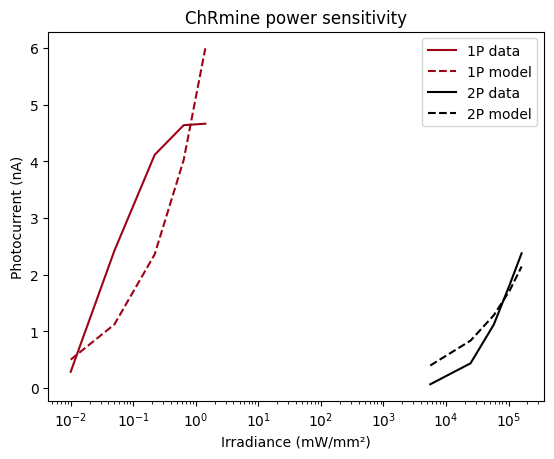

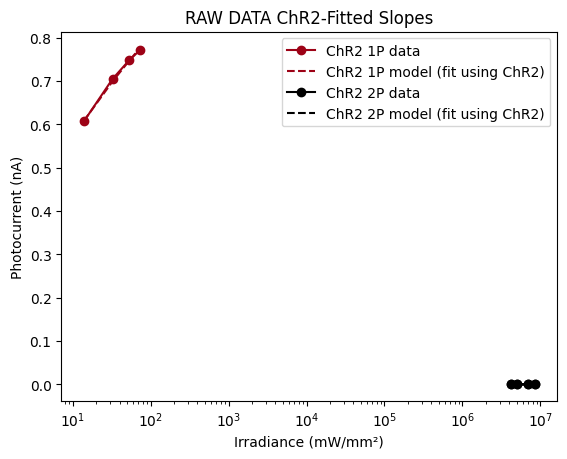

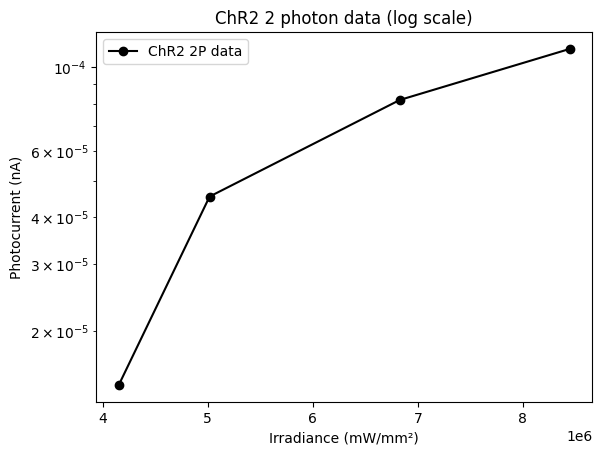

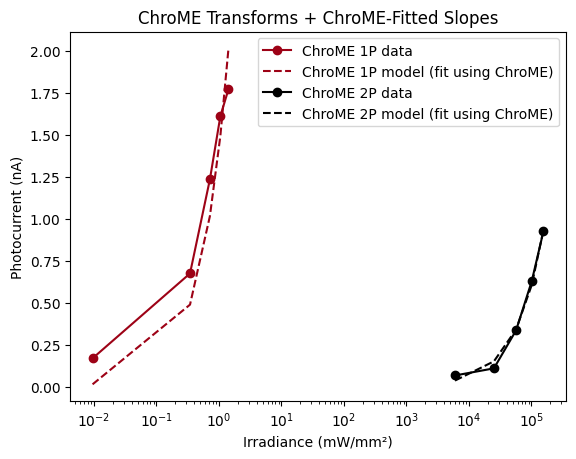

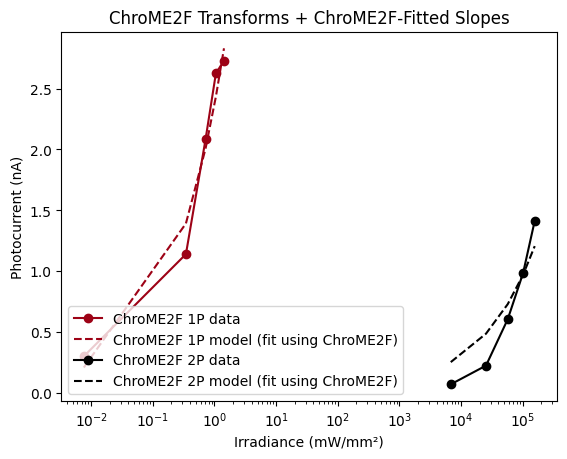

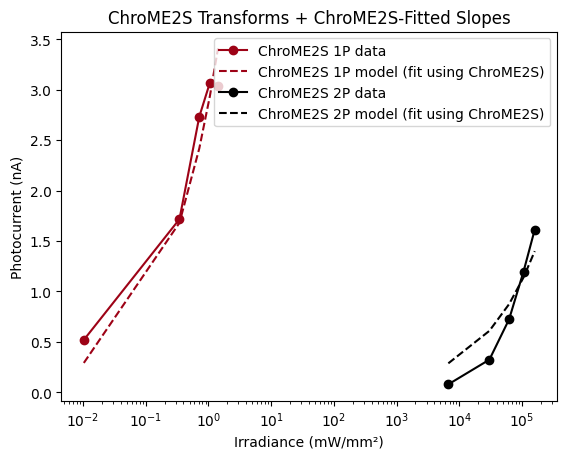

In [14]:
#made it into a function
from itertools import product
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit


def identity(x): return x
def square(x): return np.power(x, 2)
def f_lin(x, m): return x * m


fns_and_invs = [
    (identity, identity),
    (np.log, np.exp),
    (np.sqrt, square),
    (square, np.sqrt),
]


def fit_best_transform(irr_1p, I_1p, irr_2p, I_2p, verbose=True):
    """
    Finds the best (irradiance, current) transform pair for linear fitting.
    Returns the best functions, fits, predictions, and R² dataframe.

    Parameters:
    - irr_1p, I_1p: arrays of 1P irradiance and current
    - irr_2p, I_2p: arrays of 2P irradiance and current
    - verbose: if True, print best result info

    Returns:
    - best_f_irr, best_f_irr_inv
    - best_f_I, best_f_I_inv
    - best_I_hat_1p, best_I_hat_2p
    - best_m1p, best_m2p
    - r2_results_df: DataFrame of all R² comparisons
    """

    def opt(x, y):
        opt = curve_fit(f_lin, x, y, [1], full_output=True)
        m = opt[0][0]
        percent_resid2 = np.sum(opt[2]["fvec"] ** 2) / np.sum(y ** 2)
        return m, percent_resid2

    best_r2 = -np.inf
    df = pd.DataFrame(columns=["f_irr", "f_I", "r2_1p", "r2_2p", "mean_r2"])

    for (f_irr, f_irr_inv), (f_I, f_I_inv) in product(fns_and_invs, fns_and_invs):
        irr_1p_trans = f_irr(irr_1p)
        irr_2p_trans = f_irr(irr_2p)
        I_1p_trans = f_I(I_1p)
        I_2p_trans = f_I(I_2p)

        m1p, _ = opt(irr_1p_trans, I_1p_trans)
        m2p, _ = opt(irr_2p_trans, I_2p_trans)

        I_hat_1p = f_I_inv(m1p * irr_1p_trans)
        I_hat_2p = f_I_inv(m2p * irr_2p_trans)

        r2_1p = 1 - np.sum((I_hat_1p - I_1p) ** 2) / np.sum((I_1p - np.mean(I_1p)) ** 2)
        r2_2p = 1 - np.sum((I_hat_2p - I_2p) ** 2) / np.sum((I_2p - np.mean(I_2p)) ** 2)
        mean_r2 = np.mean([r2_1p, r2_2p])

        df.loc[len(df)] = [f_irr.__name__, f_I.__name__, r2_1p, r2_2p, mean_r2]

        if mean_r2 > best_r2:
            best_r2 = mean_r2
            best_f_irr, best_f_irr_inv = f_irr, f_irr_inv
            best_f_I, best_f_I_inv = f_I, f_I_inv
            best_I_hat_1p, best_I_hat_2p = I_hat_1p, I_hat_2p
            best_m1p, best_m2p = m1p, m2p

    if verbose:
        print("\n===============")
        print("    RESULTS    ")
        print("===============")
        print(f"best_f_irr: {best_f_irr.__name__}")
        print(f"best_f_I: {best_f_I.__name__}")
        print(f"best mean r2: {best_r2:.4f}")

    return (
        best_f_irr, best_f_irr_inv,
        best_f_I, best_f_I_inv,
        best_I_hat_1p, best_I_hat_2p,
        best_m1p, best_m2p,
        df
    )
(
    best_f_irr, best_f_irr_inv,
    best_f_I, best_f_I_inv,
    best_I_hat_1p, best_I_hat_2p,
    best_m1p, best_m2p,
    r2_results_df
) = fit_best_transform(irr_1p, I_1p, irr_2p, I_2p)

fig, ax = plt.subplots()

# 1P data and model (original space)
ax.semilogx(irr_1p, I_1p, c="xkcd:carmine", label="1P data")
ax.plot(
    irr_1p,
    best_f_I_inv(best_m1p * best_f_irr(irr_1p)),
    c="xkcd:carmine",
    linestyle="--",
    label="1P model",
)

# 2P data and model (original space)
ax.plot(irr_2p, I_2p, c="k", label="2P data")
ax.plot(
    irr_2p,
    best_f_I_inv(best_m2p * best_f_irr(irr_2p)),
    c="k",
    linestyle="--",
    label="2P model",
)

ax.set(
    xlabel="Irradiance (mW/mm²)",
    ylabel="Photocurrent (nA)",
    title="ChRmine power sensitivity"
)
ax.legend()

#CHR2 
chr2 = get_chr2_irradiance_data()
chr2_irr_1p = chr2["irr_1p"]
chr2_I_1p = chr2["I_1p"]
chr2_irr_2p = chr2["irr_2p"]
chr2_I_2p = chr2["I_2p"]

(best_f_irr_chr2, best_f_irr_inv_chr2,
 best_f_I_chr2, best_f_I_inv_chr2,
 best_I_hat_1p_chr2, best_I_hat_2p_chr2,
 best_m1p_chr2, best_m2p_chr2,
 r2_results_df_chr2) = fit_best_transform(
    chr2_irr_1p, chr2_I_1p, chr2_irr_2p, chr2_I_2p, verbose=False
)

fig2, ax2 = plt.subplots()
# 1P data and model (original space)
ax2.semilogx(chr2_irr_1p, chr2_I_1p, 'o-', c="xkcd:carmine", label="ChR2 1P data")
ax2.plot(
    chr2_irr_1p,
    best_f_I_inv_chr2(best_m1p_chr2 * best_f_irr_chr2(chr2_irr_1p)),
    '--', c="xkcd:carmine", label="ChR2 1P model (fit using ChR2)"
)
# 2P data and model (original space)
ax2.plot(chr2_irr_2p, chr2_I_2p, 'o-', c="k", label="ChR2 2P data")
ax2.plot(
    chr2_irr_2p,
    best_f_I_inv_chr2(best_m2p_chr2 * best_f_irr_chr2(chr2_irr_2p)),
    '--', c="k", label="ChR2 2P model (fit using ChR2)"
)
ax2.set(
    xlabel="Irradiance (mW/mm²)",
    ylabel="Photocurrent (nA)",
    title="RAW DATA ChR2-Fitted Slopes"
)
ax2.legend()

fig6, ax6 = plt.subplots()
ax6.semilogy(chr2_irr_2p, chr2_I_2p, 'o-', c="xkcd:black", label="ChR2 2P data")  
ax2.plot(chr2_irr_2p, chr2_I_2p, 'o-', c="k", label="ChR2 2P data")
ax2.plot(
    chr2_irr_2p,
    best_f_I_inv_chr2(best_m2p_chr2 * best_f_irr_chr2(chr2_irr_2p)),
    '--', c="k", label="ChR2 2P model (fit using ChR2)"
)
ax6.set(
    xlabel="Irradiance (mW/mm²)",
    ylabel="Photocurrent (nA)",
    title="ChR2 2 photon data (log scale)"
)
ax6.legend()

#chroME
chrome = get_chrome()
chrome_irr_1p = chrome["irr_1p"]
chrome_I_1p = chrome["I_1p"]
chrome_irr_2p = chrome["irr_2p"]
chrome_I_2p = chrome["I_2p"]

(best_f_irr_chrome, best_f_irr_inv_chrome,
 best_f_I_chrome, best_f_I_inv_chrome,
 best_I_hat_1p_chrome, best_I_hat_2p_chrome,
 best_m1p_chrome, best_m2p_chrome,
 r2_results_df_chrome) = fit_best_transform(
    chrome_irr_1p, chrome_I_1p, chrome_irr_2p, chrome_I_2p, verbose=False
)
fig3, ax3 = plt.subplots()
# 1P (original space)
ax3.semilogx(chrome_irr_1p, chrome_I_1p, 'o-', c="xkcd:carmine", label="ChroME 1P data")
ax3.plot(
    chrome_irr_1p,
    best_f_I_inv_chrome(best_m1p_chrome * best_f_irr_chrome(chrome_irr_1p)),
    '--', c="xkcd:carmine", label="ChroME 1P model (fit using ChroME)"
)
# 2P (original space)
ax3.plot(chrome_irr_2p, chrome_I_2p, 'o-', c="k", label="ChroME 2P data")
ax3.plot(
    chrome_irr_2p,
    best_f_I_inv_chrome(best_m2p_chrome * best_f_irr_chrome(chrome_irr_2p)),
    '--', c="k", label="ChroME 2P model (fit using ChroME)"
)
ax3.set(
    xlabel="Irradiance (mW/mm²)",
    ylabel="Photocurrent (nA)",
    title="ChroME Transforms + ChroME-Fitted Slopes"
)
ax3.legend()

#chrome2f
chrome2f = get_chrome2f()
chrome2f_irr_1p = chrome2f["irr_1p"]
chrome2f_I_1p = chrome2f["I_1p"]
chrome2f_irr_2p = chrome2f["irr_2p"]
chrome2f_I_2p = chrome2f["I_2p"]

(best_f_irr_chrome2f, best_f_irr_inv_chrome2f,
 best_f_I_chrome2f, best_f_I_inv_chrome2f,
 best_I_hat_1p_chrome2f, best_I_hat_2p_chrome2f,
 best_m1p_chrome2f, best_m2p_chrome2f,
 r2_results_df_chrome2f) = fit_best_transform(
    chrome2f_irr_1p, chrome2f_I_1p, chrome2f_irr_2p, chrome2f_I_2p, verbose=False
)
fig4, ax4 = plt.subplots()
# 1P (original space)
ax4.semilogx(chrome2f_irr_1p, chrome2f_I_1p, 'o-', c="xkcd:carmine", label="ChroME2F 1P data")
ax4.plot(
    chrome2f_irr_1p,
    best_f_I_inv_chrome2f(best_m1p_chrome2f * best_f_irr_chrome2f(chrome2f_irr_1p)),
    '--', c="xkcd:carmine", label="ChroME2F 1P model (fit using ChroME2F)"
)
# 2P (original space)
ax4.plot(chrome2f_irr_2p, chrome2f_I_2p, 'o-', c="k", label="ChroME2F 2P data")
ax4.plot(
    chrome2f_irr_2p,
    best_f_I_inv_chrome2f(best_m2p_chrome2f * best_f_irr_chrome2f(chrome2f_irr_2p)),
    '--', c="k", label="ChroME2F 2P model (fit using ChroME2F)"
)
ax4.set(
    xlabel="Irradiance (mW/mm²)",
    ylabel="Photocurrent (nA)",
    title="ChroME2F Transforms + ChroME2F-Fitted Slopes"
)
ax4.legend()

#chrome2s
chrome2s = get_chrome2s()
chrome2s_irr_1p = chrome2s["irr_1p"]
chrome2s_I_1p = chrome2s["I_1p"]
chrome2s_irr_2p = chrome2s["irr_2p"]
chrome2s_I_2p = chrome2s["I_2p"]    

(best_f_irr_chrome2s, best_f_irr_inv_chrome2s,
 best_f_I_chrome2s, best_f_I_inv_chrome2s,
 best_I_hat_1p_chrome2s, best_I_hat_2p_chrome2s,
 best_m1p_chrome2s, best_m2p_chrome2s,
 r2_results_df_chrome2s) = fit_best_transform(
    chrome2s_irr_1p, chrome2s_I_1p, chrome2s_irr_2p, chrome2s_I_2p, verbose=False
)
fig5, ax5 = plt.subplots()
# 1P (original space)
ax5.semilogx(chrome2s_irr_1p, chrome2s_I_1p, 'o-', c="xkcd:carmine", label="ChroME2S 1P data")
ax5.plot(
    chrome2s_irr_1p,
    best_f_I_inv_chrome2s(best_m1p_chrome2s * best_f_irr_chrome2s(chrome2s_irr_1p)),
    '--', c="xkcd:carmine", label="ChroME2S 1P model (fit using ChroME2S)"
)
# 2P (original space)
ax5.plot(chrome2s_irr_2p, chrome2s_I_2p, 'o-', c="k", label="ChroME2S 2P data")
ax5.plot(
    chrome2s_irr_2p,
    best_f_I_inv_chrome2s(best_m2p_chrome2s * best_f_irr_chrome2s(chrome2s_irr_2p)),
    '--', c="k", label="ChroME2S 2P model (fit using ChroME2S)"
)
ax5.set(
    xlabel="Irradiance (mW/mm²)",
    ylabel="Photocurrent (nA)",
    title="ChroME2S Transforms + ChroME2S-Fitted Slopes"
)
ax5.legend()

plt.show()


In [15]:
#cleaned up code
# made it into a function
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- transforms & inverses (safe) ---
def identity(x): return np.asarray(x, dtype=float)
def square(x):   return np.power(x, 2)

_EPS = 1e-12
def _safe_log(x):   return np.log(np.clip(np.asarray(x, float), _EPS, None))
def _safe_sqrt(x):  return np.sqrt(np.clip(np.asarray(x, float), 0.0, None))

fns_and_invs = [
    (identity,  identity),
    (_safe_log, np.exp),
    (_safe_sqrt, square),
    (square,    np.sqrt),
]

# # linear model through origin: I_hat = m * irr
# def f_lin(x, m): return x * m

def fit_best_transform(irr_1p, I_1p, irr_2p, I_2p, verbose=True):
    """
    Match the original 'expected' methodology:
      - try all (f_irr, f_I) pairs
      - fit y = m * x in TRANSFORM space via curve_fit(..., full_output=True)
      - compute percent_resid2 from the solver residual vector (in transform space)
      - inverse-map predictions back to ORIGINAL current space for R^2
      - select pair by highest mean R^2 (original space)
    Returns:
      best_f_irr, best_f_irr_inv,
      best_f_I,   best_f_I_inv,
      best_I_hat_1p, best_I_hat_2p,
      best_m1p, best_m2p,
      r2_results_df
    """
    import numpy as np
    import pandas as pd
    from scipy.optimize import curve_fit

    def f_lin(x, m):  # y = m x
        return x * m

    def opt(x, y):
        # Fit in transform space with full_output like the original block
        popt, pcov, infodict, errmsg, ier = curve_fit(
            f_lin, np.asarray(x, float), np.asarray(y, float),
            p0=[1.0], full_output=True
        )
        m = popt[0]
        # percent residual energy in transform space (use y actually passed in)
        percent_resid2 = np.sum(infodict["fvec"]**2) / np.sum(np.asarray(y, float)**2)
        return m, percent_resid2

    best_r2 = -np.inf
    df = pd.DataFrame(columns=["f_irr", "f_I", "r2_1p", "r2_2p", "mean_r2"])

    # iterate over transform pairs exactly like your script
    for (f_irr, f_irr_inv), (f_I, f_I_inv) in product(fns_and_invs, fns_and_invs):
        # transform axes
        irr_1p_trans = f_irr(irr_1p)
        irr_2p_trans = f_irr(irr_2p)
        I_1p_trans   = f_I(I_1p)
        I_2p_trans   = f_I(I_2p)

        # fit slopes in transform space
        m1p, res1 = opt(irr_1p_trans, I_1p_trans)
        m2p, res2 = opt(irr_2p_trans, I_2p_trans)
        _ = 0.5 * (res1 + res2)  # tot_res (not used for selection, kept for parity)

        # predictions mapped back to ORIGINAL current space
        I_hat_1p = f_I_inv(m1p * irr_1p_trans)
        I_hat_2p = f_I_inv(m2p * irr_2p_trans)

        I_1p = np.asarray(I_1p, float)
        I_2p = np.asarray(I_2p, float)
        r2_1p = 1.0 - np.sum((I_hat_1p - I_1p)**2) / np.sum((I_1p - I_1p.mean())**2)
        r2_2p = 1.0 - np.sum((I_hat_2p - I_2p)**2) / np.sum((I_2p - I_2p.mean())**2)
        mean_r2 = 0.5 * (r2_1p + r2_2p)

        df.loc[len(df)] = [f_irr.__name__, f_I.__name__, r2_1p, r2_2p, mean_r2]

        if mean_r2 > best_r2:
            best_r2 = mean_r2
            best_f_irr, best_f_irr_inv = f_irr, f_irr_inv
            best_f_I,   best_f_I_inv   = f_I,   f_I_inv
            best_I_hat_1p, best_I_hat_2p = I_hat_1p, I_hat_2p
            best_m1p, best_m2p = m1p, m2p

    if verbose:
        print("\n===============")
        print("    RESULTS    ")
        print("===============")
        print(f"best_f_irr: {best_f_irr.__name__}")
        print(f"best_f_I: {best_f_I.__name__}")
        print(f"best mean r2: {best_r2:.4f}")

    return (
        best_f_irr, best_f_irr_inv,
        best_f_I,   best_f_I_inv,
        best_I_hat_1p, best_I_hat_2p,
        best_m1p, best_m2p,
    )


# === usage (unchanged downstream) ===
(best_f_irr, best_f_irr_inv,
 best_f_I, best_f_I_inv,
 best_I_hat_1p, best_I_hat_2p,
 best_m1p, best_m2p,
 r2_results_df) = fit_best_transform(irr_1p, I_1p, irr_2p, I_2p)

fig, ax = plt.subplots()

# 1P data and model (original space)
ax.semilogx(irr_1p, I_1p, c="xkcd:carmine", label="1P data")
ax.plot(
    irr_1p,
    best_f_I_inv(best_m1p * best_f_irr(irr_1p)),
    c="xkcd:carmine", linestyle="--", label="1P model",
)

# 2P data and model (original space)
ax.plot(irr_2p, I_2p, c="k", label="2P data")
ax.plot(
    irr_2p,
    best_f_I_inv(best_m2p * best_f_irr(irr_2p)),
    c="k", linestyle="--", label="2P model",
)

ax.set(xlabel="Irradiance (mW/mm²)", ylabel="Photocurrent (nA)",
       title="ChRmine power sensitivity")
ax.legend()

# CHR2
chr2 = get_chr2_irradiance_data()
chr2_irr_1p = chr2["irr_1p"]
chr2_I_1p = chr2["I_1p"]
chr2_irr_2p = chr2["irr_2p"]
chr2_I_2p = chr2["I_2p"]

(best_f_irr_chr2, best_f_irr_inv_chr2,
 best_f_I_chr2, best_f_I_inv_chr2,
 best_I_hat_1p_chr2, best_I_hat_2p_chr2,
 best_m1p_chr2, best_m2p_chr2,
 r2_results_df_chr2) = fit_best_transform(
    chr2_irr_1p, chr2_I_1p, chr2_irr_2p, chr2_I_2p, verbose=False
)

fig2, ax2 = plt.subplots()
ax2.semilogx(chr2_irr_1p, chr2_I_1p, 'o-', c="xkcd:carmine", label="ChR2 1P data")
ax2.plot(
    chr2_irr_1p,
    best_f_I_inv_chr2(best_m1p_chr2 * best_f_irr_chr2(chr2_irr_1p)),
    '--', c="xkcd:carmine", label="ChR2 1P model (fit using ChR2)"
)
ax2.plot(chr2_irr_2p, chr2_I_2p, 'o-', c="k", label="ChR2 2P data")
ax2.plot(
    chr2_irr_2p,
    best_f_I_inv_chr2(best_m2p_chr2 * best_f_irr_chr2(chr2_irr_2p)),
    '--', c="k", label="ChR2 2P model (fit using ChR2)"
)
ax2.set(xlabel="Irradiance (mW/mm²)", ylabel="Photocurrent (nA)",
        title="RAW DATA ChR2-Fitted Slopes")
ax2.legend()

# chroME
chrome = get_chrome()
chrome_irr_1p = chrome["irr_1p"]; chrome_I_1p = chrome["I_1p"]
chrome_irr_2p = chrome["irr_2p"]; chrome_I_2p = chrome["I_2p"]

(best_f_irr_chrome, best_f_irr_inv_chrome,
 best_f_I_chrome, best_f_I_inv_chrome,
 best_I_hat_1p_chrome, best_I_hat_2p_chrome,
 best_m1p_chrome, best_m2p_chrome,
 r2_results_df_chrome) = fit_best_transform(
    chrome_irr_1p, chrome_I_1p, chrome_irr_2p, chrome_I_2p, verbose=False
)

fig3, ax3 = plt.subplots()
ax3.semilogx(chrome_irr_1p, chrome_I_1p, 'o-', c="xkcd:carmine", label="ChroME 1P data")
ax3.plot(
    chrome_irr_1p,
    best_f_I_inv_chrome(best_m1p_chrome * best_f_irr_chrome(chrome_irr_1p)),
    '--', c="xkcd:carmine", label="ChroME 1P model (fit using ChroME)"
)
ax3.plot(chrome_irr_2p, chrome_I_2p, 'o-', c="k", label="ChroME 2P data")
ax3.plot(
    chrome_irr_2p,
    best_f_I_inv_chrome(best_m2p_chrome * best_f_irr_chrome(chrome_irr_2p)),
    '--', c="k", label="ChroME 2P model (fit using ChroME)"
)
ax3.set(xlabel="Irradiance (mW/mm²)", ylabel="Photocurrent (nA)",
        title="ChroME Transforms + ChroME-Fitted Slopes")
ax3.legend()

# chroME2f
chrome2f = get_chrome2f()
chrome2f_irr_1p = chrome2f["irr_1p"]; chrome2f_I_1p = chrome2f["I_1p"]
chrome2f_irr_2p = chrome2f["irr_2p"]; chrome2f_I_2p = chrome2f["I_2p"]

(best_f_irr_chrome2f, best_f_irr_inv_chrome2f,
 best_f_I_chrome2f, best_f_I_inv_chrome2f,
 best_I_hat_1p_chrome2f, best_I_hat_2p_chrome2f,
 best_m1p_chrome2f, best_m2p_chrome2f,
 r2_results_df_chrome2f) = fit_best_transform(
    chrome2f_irr_1p, chrome2f_I_1p, chrome2f_irr_2p, chrome2f_I_2p, verbose=False
)

fig4, ax4 = plt.subplots()
ax4.semilogx(chrome2f_irr_1p, chrome2f_I_1p, 'o-', c="xkcd:carmine", label="ChroME2F 1P data")
ax4.plot(
    chrome2f_irr_1p,
    best_f_I_inv_chrome2f(best_m1p_chrome2f * best_f_irr_chrome2f(chrome2f_irr_1p)),
    '--', c="xkcd:carmine", label="ChroME2F 1P model (fit using ChroME2F)"
)
ax4.plot(chrome2f_irr_2p, chrome2f_I_2p, 'o-', c="k", label="ChroME2F 2P data")
ax4.plot(
    chrome2f_irr_2p,
    best_f_I_inv_chrome2f(best_m2p_chrome2f * best_f_irr_chrome2f(chrome2f_irr_2p)),
    '--', c="k", label="ChroME2F 2P model (fit using ChroME2F)"
)
ax4.set(xlabel="Irradiance (mW/mm²)", ylabel="Photocurrent (nA)",
        title="ChroME2F Transforms + ChroME2F-Fitted Slopes")
ax4.legend()

# chroME2s
chrome2s = get_chrome2s()
chrome2s_irr_1p = chrome2s["irr_1p"]; chrome2s_I_1p = chrome2s["I_1p"]
chrome2s_irr_2p = chrome2s["irr_2p"]; chrome2s_I_2p = chrome2s["I_2p"]

(best_f_irr_chrome2s, best_f_irr_inv_chrome2s,
 best_f_I_chrome2s, best_f_I_inv_chrome2s,
 best_I_hat_1p_chrome2s, best_I_hat_2p_chrome2s,
 best_m1p_chrome2s, best_m2p_chrome2s,
 r2_results_df_chrome2s) = fit_best_transform(
    chrome2s_irr_1p, chrome2s_I_1p, chrome2s_irr_2p, chrome2s_I_2p, verbose=False
)

fig5, ax5 = plt.subplots()
ax5.semilogx(chrome2s_irr_1p, chrome2s_I_1p, 'o-', c="xkcd:carmine", label="ChroME2S 1P data")
ax5.plot(
    chrome2s_irr_1p,
    best_f_I_inv_chrome2s(best_m1p_chrome2s * best_f_irr_chrome2s(chrome2s_irr_1p)),
    '--', c="xkcd:carmine", label="ChroME2S 1P model (fit using ChroME2S)"
)
ax5.plot(chrome2s_irr_2p, chrome2s_I_2p, 'o-', c="k", label="ChroME2S 2P data")
ax5.plot(
    chrome2s_irr_2p,
    best_f_I_inv_chrome2s(best_m2p_chrome2s * best_f_irr_chrome2s(chrome2s_irr_2p)),
    '--', c="k", label="ChroME2S 2P model (fit using ChroME2S)"
)
ax5.set(xlabel="Irradiance (mW/mm²)", ylabel="Photocurrent (nA)",
        title="ChroME2S Transforms + ChroME2S-Fitted Slopes")
ax5.legend()

plt.show()

# expose the results table
r2_results_df


WARNING    /var/folders/k8/vkc87z_97_9d7gp2l0pm5khr0000gn/T/ipykernel_12271/3140863352.py:76: RuntimeWarning: invalid value encountered in sqrt
  I_hat_1p = f_I_inv(m1p * irr_1p_trans)
 [py.warnings]



    RESULTS    
best_f_irr: _safe_sqrt
best_f_I: identity
best mean r2: 0.7039


ValueError: not enough values to unpack (expected 9, got 8)


    RESULTS    
best_f_irr: sqrt
best_f_I: identity
best mean r2 0.703853307246795


/var/folders/k8/vkc87z_97_9d7gp2l0pm5khr0000gn/T/ipykernel_87002/3985390862.py:48: RuntimeWarning: invalid value encountered in sqrt
  I_hat_1p = f_I_inv(m1p * irr_1p_transformed)


,f_irr,f_I,r2_1p,r2_2p,mean_r2
0,identity,identity,-0.460178,0.970862,0.255342
1,identity,log,-0.596008,0.556113,-0.019947
2,identity,sqrt,-1.989953,0.494364,-0.747795
3,identity,square,0.447950,0.886708,0.667329
4,log,identity,-3.182423,0.274285,-1.454069
5,log,log,-1.775753,-0.245836,-1.010795
6,log,sqrt,-3.516459,0.411338,-1.552560
7,log,square,NaN,0.024131,NaN
8,sqrt,identity,0.506932,0.900775,0.703853
9,sqrt,log,0.171196,0.204009,0.187602


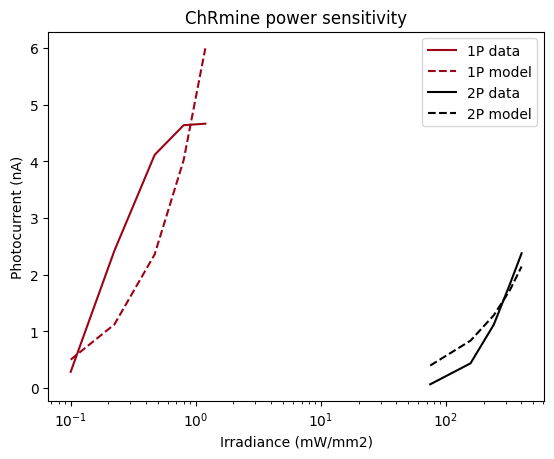

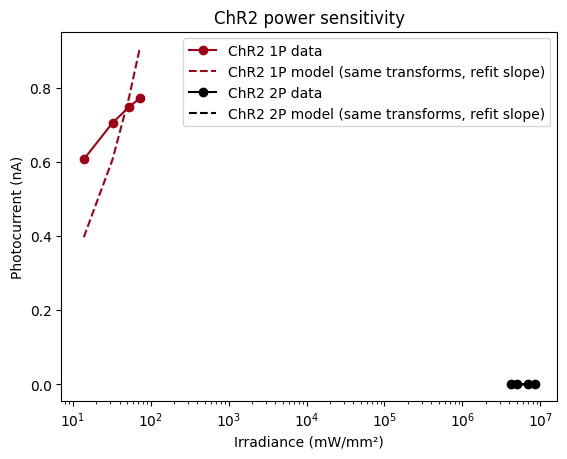

In [ ]:
from itertools import product
import pandas as pd
from scipy.optimize import curve_fit


# can we get a good linear fit
def identity(x):
    return np.multiply(x, 1)


def square(x):
    return np.power(x, 2)


fns_and_invs = [
    (identity, identity),
    (np.log, np.exp),
    (np.sqrt, square),
    (square, np.sqrt),
]


def f_lin(x, m):
    return x * m


def opt(irr, I):
    opt = curve_fit(f_lin, irr, I, [1], full_output=True)
    m = opt[0][0]
    percent_resid2 = np.sum(opt[2]["fvec"] ** 2) / np.sum(I_1p_transformed**2)
    return m, percent_resid2


best_res = np.inf
best_r2 = -np.inf
df = pd.DataFrame(columns=["f_irr", "f_I", "r2_1p", "r2_2p", "mean_r2"])
for (f_irr, f_irr_inv), (f_I, f_I_inv) in product(fns_and_invs, fns_and_invs):
    irr_1p_transformed = f_irr(irr_1p)
    irr_2p_transformed = f_irr(irr_2p)
    I_1p_transformed = f_I(I_1p)
    I_2p_transformed = f_I(I_2p)

    m1p, percent_resid2_1p = opt(irr_1p_transformed, I_1p_transformed)
    m2p, percent_resid2_2p = opt(irr_2p_transformed, I_2p_transformed)
    # print(percent_resid2_1p, percent_resid2_2p)
    tot_res = np.mean([percent_resid2_1p, percent_resid2_2p])

    I_hat_1p = f_I_inv(m1p * irr_1p_transformed)
    r2_1p = 1 - np.sum((I_hat_1p - I_1p) ** 2) / np.sum((I_1p - np.mean(I_1p)) ** 2)
    # r2_1p = np.corrcoef(I_1p, I_hat_1p)[0, 1] ** 2

    I_hat_2p = f_I_inv(m2p * irr_2p_transformed)
    r2_2p = 1 - np.sum((I_hat_2p - I_2p) ** 2) / np.sum((I_2p - np.mean(I_2p)) ** 2)
    # r2_2p = np.corrcoef(I_2p, I_hat_2p)[0, 1] ** 2

    mean_r2 = np.mean([r2_1p, r2_2p])

    df.loc[len(df)] = [f_irr.__name__, f_I.__name__, r2_1p, r2_2p, mean_r2]
    # print(
    #     f"f_irr={f_irr.__name__}, f_I={f_I.__name__}, r2_1p={r2_1p:.3f}, r2_2p={r2_2p:.3f}"
    # )

    # if tot_res < best_res:
    if mean_r2 > best_r2:
        # best_res = tot_res
        best_r2 = mean_r2
        best_f_irr = f_irr
        best_f_I = f_I
        best_I_hat_1p = I_hat_1p
        best_I_hat_2p = I_hat_2p
print("\n===============")
print("    RESULTS    ")
print("===============")
print(f"best_f_irr: {best_f_irr.__name__}")
print(f"best_f_I: {best_f_I.__name__}")
# print(f"best mean resid: {best_res}")
print("best mean r2", best_r2)

fig, ax = plt.subplots()
ax.semilogx(best_f_irr(irr_1p), best_f_I(I_1p), c="xkcd:carmine", label="1P data")
ax.plot(
    best_f_irr(irr_1p),
    best_I_hat_1p,
    c="xkcd:carmine",
    linestyle="--",
    label="1P model",
)
ax.plot(best_f_irr(irr_2p), best_f_I(I_2p), c="k", label="2P data")
ax.plot(best_f_irr(irr_2p), best_I_hat_2p, c="k", linestyle="--", label="2P model")
ax.set(
    xlabel="Irradiance (mW/mm2)",
    ylabel="Photocurrent (nA)",
    title="ChRmine power sensitivity",
)
ax.legend()


# CHR2
chr2 = get_chr2_irradiance_data()
chr2_irr_1p = chr2["irr_1p"]
chr2_I_1p   = chr2["I_1p"]
chr2_irr_2p = chr2["irr_2p"]
chr2_I_2p   = chr2["I_2p"]

# --- CHR2 (same style as first block) ---

# fetch data
chr2 = get_chr2_irradiance_data()
chr2_irr_1p = chr2["irr_1p"]
chr2_I_1p   = chr2["I_1p"]
chr2_irr_2p = chr2["irr_2p"]
chr2_I_2p   = chr2["I_2p"]

# transform using the already-selected best transforms
chr2_irr_1p_trans = best_f_irr(chr2_irr_1p)
chr2_I_1p_trans   = best_f_I(chr2_I_1p)
chr2_irr_2p_trans = best_f_irr(chr2_irr_2p)
chr2_I_2p_trans   = best_f_I(chr2_I_2p)

# slope through origin in transform space (same math as inside fit_best_transform)
def _fit_slope_through_origin(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    return np.dot(x, y) / np.dot(x, x)

best_m1p_chr2 = _fit_slope_through_origin(chr2_irr_1p_trans, chr2_I_1p_trans)
best_m2p_chr2 = _fit_slope_through_origin(chr2_irr_2p_trans, chr2_I_2p_trans)

# predictions back in ORIGINAL current space (nA)
best_I_hat_1p_chr2 = best_f_I_inv(best_m1p_chr2 * chr2_irr_1p_trans)
best_I_hat_2p_chr2 = best_f_I_inv(best_m2p_chr2 * chr2_irr_2p_trans)

# plot in ORIGINAL space (same style)
fig2, ax2 = plt.subplots()
ax2.semilogx(chr2_irr_1p, chr2_I_1p, 'o-', c="xkcd:carmine", label="ChR2 1P data")
ax2.plot(
    chr2_irr_1p,
    best_I_hat_1p_chr2,
    '--', c="xkcd:carmine",
    label="ChR2 1P model (same transforms, refit slope)"
)
ax2.plot(chr2_irr_2p, chr2_I_2p, 'o-', c="k", label="ChR2 2P data")
ax2.plot(
    chr2_irr_2p,
    best_I_hat_2p_chr2,
    '--', c="k",
    label="ChR2 2P model (same transforms, refit slope)"
)
ax2.set(
    xlabel="Irradiance (mW/mm²)",
    ylabel="Photocurrent (nA)",
    title="ChR2 power sensitivity"
)
ax2.legend()

df

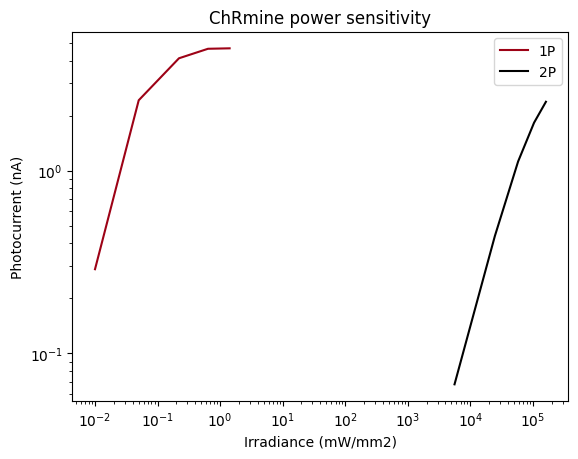

In [ ]:
fig, ax = plt.subplots()
ax.loglog((irr_1p), (I_1p), c="xkcd:carmine", label="1P")
ax.plot((irr_2p), (I_2p), c="k", label="2P")
ax.set(
    xlabel="Irradiance (mW/mm2)",
    ylabel="Photocurrent (nA)",
    title="ChRmine power sensitivity",
)
ax.legend()


    RESULTS    
best_f_irr: sqrt
best_f_I: identity
best mean r2 0.703853307246795


/var/folders/k8/vkc87z_97_9d7gp2l0pm5khr0000gn/T/ipykernel_87002/3855453677.py:48: RuntimeWarning: invalid value encountered in sqrt
  I_hat_1p = f_I_inv(m1p * irr_1p_transformed)


,f_irr,f_I,r2_1p,r2_2p,mean_r2
0,identity,identity,-0.460178,0.970862,0.255342
1,identity,log,-0.596008,0.556113,-0.019947
2,identity,sqrt,-1.989953,0.494364,-0.747795
3,identity,square,0.447950,0.886708,0.667329
4,log,identity,-3.182423,0.274285,-1.454069
5,log,log,-1.775753,-0.245836,-1.010795
6,log,sqrt,-3.516459,0.411338,-1.552560
7,log,square,NaN,0.024131,NaN
8,sqrt,identity,0.506932,0.900775,0.703853
9,sqrt,log,0.171196,0.204009,0.187602


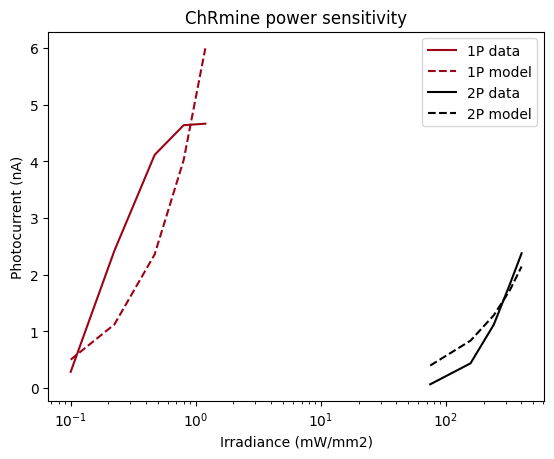

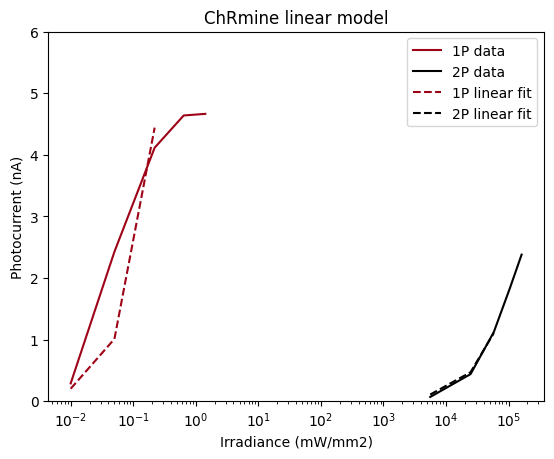

In [ ]:
from itertools import product
import pandas as pd
from scipy.optimize import curve_fit


# can we get a good linear fit
def identity(x):
    return np.multiply(x, 1)


def square(x):
    return np.power(x, 2)


fns_and_invs = [
    (identity, identity),
    (np.log, np.exp),
    (np.sqrt, square),
    (square, np.sqrt),
]


def f_lin(x, m):
    return x * m


def opt(irr, I):
    opt = curve_fit(f_lin, irr, I, [1], full_output=True)
    m = opt[0][0]
    percent_resid2 = np.sum(opt[2]["fvec"] ** 2) / np.sum(I_1p_transformed**2)
    return m, percent_resid2


best_res = np.inf
best_r2 = -np.inf
df = pd.DataFrame(columns=["f_irr", "f_I", "r2_1p", "r2_2p", "mean_r2"])
for (f_irr, f_irr_inv), (f_I, f_I_inv) in product(fns_and_invs, fns_and_invs):
    irr_1p_transformed = f_irr(irr_1p)
    irr_2p_transformed = f_irr(irr_2p)
    I_1p_transformed = f_I(I_1p)
    I_2p_transformed = f_I(I_2p)

    m1p, percent_resid2_1p = opt(irr_1p_transformed, I_1p_transformed)
    m2p, percent_resid2_2p = opt(irr_2p_transformed, I_2p_transformed)
    # print(percent_resid2_1p, percent_resid2_2p)
    tot_res = np.mean([percent_resid2_1p, percent_resid2_2p])

    I_hat_1p = f_I_inv(m1p * irr_1p_transformed)
    r2_1p = 1 - np.sum((I_hat_1p - I_1p) ** 2) / np.sum((I_1p - np.mean(I_1p)) ** 2)
    # r2_1p = np.corrcoef(I_1p, I_hat_1p)[0, 1] ** 2

    I_hat_2p = f_I_inv(m2p * irr_2p_transformed)
    r2_2p = 1 - np.sum((I_hat_2p - I_2p) ** 2) / np.sum((I_2p - np.mean(I_2p)) ** 2)
    # r2_2p = np.corrcoef(I_2p, I_hat_2p)[0, 1] ** 2

    mean_r2 = np.mean([r2_1p, r2_2p])

    df.loc[len(df)] = [f_irr.__name__, f_I.__name__, r2_1p, r2_2p, mean_r2]
    # print(
    #     f"f_irr={f_irr.__name__}, f_I={f_I.__name__}, r2_1p={r2_1p:.3f}, r2_2p={r2_2p:.3f}"
    # )

    # if tot_res < best_res:
    if mean_r2 > best_r2:
        # best_res = tot_res
        best_r2 = mean_r2
        best_f_irr = f_irr
        best_f_I = f_I
        best_f_I_inv = f_I_inv #inverse of f_I
        best_I_hat_1p = I_hat_1p
        best_I_hat_2p = I_hat_2p
print("\n===============")
print("    RESULTS    ")
print("===============")
print(f"best_f_irr: {best_f_irr.__name__}")
print(f"best_f_I: {best_f_I.__name__}")
# print(f"best mean resid: {best_res}")
print("best mean r2", best_r2)

# fig, ax = plt.subplots()
fig1, ax1 = plt.subplots()
ax1.semilogx(best_f_irr(irr_1p), best_f_I(I_1p), c="xkcd:carmine", label="1P data")
ax1.plot(
    best_f_irr(irr_1p),
    best_I_hat_1p,
    c="xkcd:carmine",
    linestyle="--",
    label="1P model",
)
ax1.plot(best_f_irr(irr_2p), best_f_I(I_2p), c="k", label="2P data")
ax1.plot(best_f_irr(irr_2p), best_I_hat_2p, c="k", linestyle="--", label="2P model")
ax1.set(
    xlabel="Irradiance (mW/mm2)",
    ylabel="Photocurrent (nA)",
    title="ChRmine power sensitivity",
)
ax1.legend()

#linear data
fig2, ax2 = plt.subplots()
ax2.set_ylim(0, 6) #to match the original plot
ax2.semilogx(irr_1p, I_1p, c="xkcd:carmine", label="1P data") #original data
ax2.plot(
    irr_2p, I_2p, c="k", label="2P data"
)


#m1p and m2p eqs from lower block
irr_1p_linear = irr_1p[:3]
I_1p_linear = I_1p[:3]
m1p, _ = opt(irr_1p_linear, I_1p_linear)#only using the LINEAR part of the curves
# m2p, _ = opt(irr_2p, I_2p)
irr_2p_linear = irr_2p[:3]
I_2p_linear = I_2p[:3]
m2p, _ = opt(irr_2p_linear, I_2p_linear)
sensitivity_ratio = m1p / m2p

ax2.plot(irr_1p_linear, m1p * irr_1p_linear, c="xkcd:carmine", linestyle="--", label="1P linear fit") #1P linear model 
ax2.plot(irr_2p_linear, m2p * irr_2p_linear, c="k", linestyle="--", label="2P linear fit") #2p linear model

ax2.set(
    xlabel="Irradiance (mW/mm2)",
    ylabel="Photocurrent (nA)",
    title="ChRmine linear model",
)
ax2.legend()


#linear part of the data
# irr_1p_linear = irr_1p[:3]
# I_1p_linear = I_1p[:3]
# irr_2p_linear = irr_2p[:3]
# I_2p_linear = I_2p[:3]

# # Transform the linear part of the data
# irr_1p_trans = best_f_irr(irr_1p_linear)
# I_1p_trans = best_f_I(I_1p_linear)
# irr_2p_trans = best_f_irr(irr_2p_linear)
# I_2p_trans = best_f_I(I_2p_linear)


# m1p, _ = opt(irr_1p_trans, I_1p_trans)
# m2p, _ = opt(irr_2p_trans, I_2p_trans)
# sensitivity_ratio = m1p / m2p

# #rescale to original units
# I_hat_1p = best_f_I_inv(m1p * irr_1p_trans)
# I_hat_2p = best_f_I_inv(m2p * irr_2p_trans)

# ax2.plot(irr_1p, I_1p, c="xkcd:carmine", label="1P data")
# ax2.plot(irr_2p, I_2p, c="k", label="2P data")
# ax2.plot(irr_1p_linear, I_hat_1p, c="xkcd:carmine", linestyle="--", label="1P linear fit (transformed)")
# ax2.plot(irr_2p_linear, I_hat_2p, c="k", linestyle="--", label="2P linear fit (transformed)")

# ax2.set(
#     xlabel="Irradiance (mW/mm2)",
#     ylabel="Photocurrent (nA)",
#     title="ChRmine linear fit using transformed early region",
# )
# ax2.legend()


df

Okay, but we do actually need a pure linear function if we want just a constant.
Let's compute that ratio to use as a placeholder for now:

In [ ]:
m1p, _ = opt(irr_1p, I_1p)
m2p, _ = opt(irr_2p, I_2p)
sensitivity_ratio = m1p / m2p

print(f"1P/2P sensitivity ratio: {sensitivity_ratio:.3f}")

1P/2P sensitivity ratio: 270382.300


In [ ]:
best_m1p_chr2, _ = opt(chr2_irr_1p, chr2_I_1p)
best_m2p_chr2, _ = opt(chr2_irr_2p, chr2_I_2p)
sensitivity_ratio_chr2 = best_m1p_chr2 / best_m2p_chr2
print(f"ChR2 1P/2P sensitivity ratio: {sensitivity_ratio_chr2:.3f}")

ChR2 1P/2P sensitivity ratio: 1217128552.608


In [ ]:
best_m1p_chrome2f, _ = opt(chrome2f_irr_1p, chrome2f_I_1p)
best_m2p_chrome2f, _ = opt(chrome2f_irr_2p, chrome2f_I_2p)
sensitivity_ratio_chrome2f = best_m1p_chrome2f / best_m2p_chrome2f
print(f"ChroME2F 1P/2P sensitivity ratio: {sensitivity_ratio_chrome2f:.3f}")

ChroME2F 1P/2P sensitivity ratio: 241883.711


In [ ]:
best_m1p_chrome, _ = opt(chrome_irr_1p, chrome_I_1p)
best_m2p_chrome, _ = opt(chrome_irr_2p, chrome_I_2p)
sensitivity_ratio_chrome = best_m1p_chrome / best_m2p_chrome
print(f"ChroME 1P/2P sensitivity ratio: {sensitivity_ratio_chrome:.3f}")

ChroME 1P/2P sensitivity ratio: 236723.197


In [ ]:
best_m1p_chrome2s, _ = opt(chrome2s_irr_1p, chrome2s_I_1p)
best_m2p_chrome2s, _ = opt(chrome2s_irr_2p, chrome2s_I_2p)
sensitivity_ratio_chrome2s = best_m1p_chrome2s / best_m2p_chrome2s
print(f"ChroME2S 1P/2P sensitivity ratio: {sensitivity_ratio_chrome2s:.3f}")

ChroME2S 1P/2P sensitivity ratio: 252587.017


In [ ]:
print(np.mean([sensitivity_ratio_chrome2s, sensitivity_ratio_chrome , sensitivity_ratio_chrome2f , sensitivity_ratio]))
